# 05. Language Model Training

From here on out we start with more practical examples and demos.

## Weight fusion

A process where you optimize the weights of an already pre-trained model in order to speed up inference. We lose the ability to inspect the weights tho. 

It changes the architecture of the model in a way that it works more in parrallel and it is in better order for the GPU cores. It trains/inferences faster.

In [4]:
!pip -q install -U datasets accelerate peft evaluate bitsandbytes

This command is essentially the "Foundation Model Starter Kit." By running this, you are installing the specific libraries required to take a massive, pre-trained model (like DINOv2 or Gemma) and perform PEFT (Parameter-Efficient Fine-Tuning). This allows you to train these huge models on your RTX 2060 Super without running out of VRAM.

If you were to fine-tune a model now, the workflow would look like this:

- datasets pulls the images.

- bitsandbytes "squeezes" the model so it fits on your 2060 Super.

- peft adds a tiny "adapter" (like a specialized lens) to the model.

- accelerate handles the communication between the code and your GPU.

### [Dataset](https://www.kaggle.com/datasets/mahmoudreda55/satellite-image-classification)

[Models](https://keras.io/api/applications/)

In [170]:
import kagglehub
import os
import numpy as np

from keras.applications.efficientnet_v2 import EfficientNetV2S, preprocess_input, decode_predictions 
from keras.layers import GlobalAvgPool2D, Dense
from keras.models import Sequential
from keras.preprocessing import image_dataset_from_directory

from skimage.io import imread, show
from skimage.color import rgba2rgb
from skimage.transform import resize

import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.io import decode_image

In [6]:
path = kagglehub.dataset_download("mahmoudreda55/satellite-image-classification")

path

'/home/alpine/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1'

In [9]:
os.listdir("/home/alpine/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data")

['cloudy', 'green_area', 'water', 'desert']

In [11]:
model = EfficientNetV2S()

I0000 00:00:1770734251.442297   30997 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:08:00.0, compute capability: 7.5


87549136/87549136 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step 


Often when we read/work with images we get UINT tensor not FLOAT. Is is crucial that we convert to float.

In [16]:
imread(os.path.join(path,"data" , "cloudy","train_10333.jpg"))

array([[[ 87,  83,  95,   0],
        [ 88,  83,  95,   0],
        [ 88,  83,  95,   0],
        ...,
        [160, 143, 147,   0],
        [163, 144, 149,   0],
        [166, 144, 149,   0]],

       [[ 84,  80,  91,   0],
        [ 86,  81,  93,   0],
        [ 87,  83,  94,   0],
        ...,
        [160, 144, 148,   0],
        [163, 145, 149,   0],
        [165, 145, 150,   0]],

       [[ 78,  76,  86,   0],
        [ 82,  79,  90,   0],
        [ 86,  82,  93,   0],
        ...,
        [161, 147, 150,   0],
        [164, 148, 151,   0],
        [166, 148, 151,   0]],

       ...,

       [[120, 109, 117,   0],
        [116, 106, 114,   0],
        [110, 102, 109,   0],
        ...,
        [130, 120, 124,   0],
        [135, 125, 130,   0],
        [138, 128, 135,   0]],

       [[122, 110, 119,   0],
        [117, 107, 115,   0],
        [110, 103, 110,   0],
        ...,
        [118, 110, 115,   0],
        [124, 116, 122,   0],
        [128, 119, 128,   0]],

       [[123

Notice here `dtype=unit8` ^^^^^^^^^^^^^^^^^^^^

In [19]:
image = imread(os.path.join(path,"data" , "cloudy","train_10333.jpg")).astype(float)

In [21]:
np.array([image]).shape

(1, 256, 256, 4)

We do this to get a batch of the image. This allows us to test with a single image. The model expects a batch, that is why we do it.

In [24]:
model.predict(np.array([image]))

ValueError: Input 0 of layer "efficientnetv2-s" is incompatible with the layer: expected shape=(None, 384, 384, 3), found shape=(1, 256, 256, 4)

We can see it expects 3 channels in the end, but we give it 4. Also the image size is wrong.

Sometimes there is preprocessing that needs to happen manually.

The image is in RGBA format, we need it to be in RBA so:

In [26]:
rgba2rgb(image)

array([[[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       ...,

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]]])

## Aspect ratio

The models expect square images. Usually images come in different aspect ratios. During the preprocessing step they will be made to be sqaure.

Problem is that their performance may vary. If a tall image doesn't have many representatives in the dataset, it might struggle to perform well on such images, due to lack of data.

<img src="Images/aspect_ration.png" width=600>

Splitting the images on patches in ViTs solves this problem.

In [48]:
image = imread("Images/cat.webp")

In [52]:
image = preprocess_input(image)

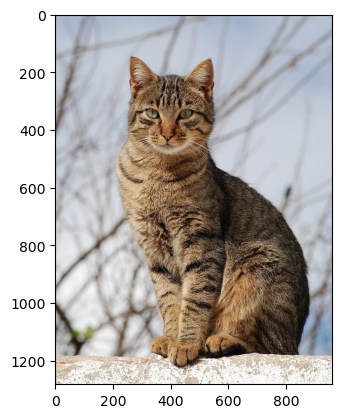

In [53]:
plt.imshow(image)

In [50]:
resized_image = resize(image, (384,384,3), preserve_range = True) # preserve_range = True is very important or it will make it [0, 1] values

image_preprocessed = np.array([resized_image]).astype(float)

In [54]:
predictions = model.predict(image_preprocessed)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step


In [55]:
decode_predictions(predictions)

[[('n02123159', 'tiger_cat', 0.3637347),
  ('n02123045', 'tabby', 0.35188973),
  ('n02124075', 'Egyptian_cat', 0.19857907),
  ('n02127052', 'lynx', 0.004343684),
  ('n02129604', 'tiger', 0.0015294397)]]

This the top-5 metric. We want the actual class we measure against to be in the top 5 classes of the model. 

If there are different species in the model classes this metric is better than top-1 which is just accuracy.

In [56]:
feature_extractor = EfficientNetV2S(include_top = False)

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step 


In [59]:
feature_extractor.predict(image_preprocessed).shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


(1, 12, 12, 1280)

In [63]:
feature_map = feature_extractor.predict(image_preprocessed)
result = GlobalAvgPool2D()(feature_map)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step


In [65]:
Dense(2, activation = "sigmoid")(result)

<tf.Tensor: shape=(1, 2), dtype=float32, numpy=array([[0.61305887, 0.54039025]], dtype=float32)>

In [72]:
feature_extractor.compile(loss = "binary_crossentropy") # This wont work. We need a custom model:

In [69]:
custom_classification_model = Sequential([
    feature_extractor,
    GlobalAvgPool2D(),
    Dense(2, activation = "sigmoid"),
    
])

In [70]:
custom_classification_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-s (Functional)   │ (None, None, None,     │    20,331,360 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,333,922 (77.57 MB)

 Trainable params: 20,180,050 (76.98 MB)

 Non-trainable params: 153,872 (601.06 KB)

In [71]:
custom_classification_model.compile(loss = "binary_crossentropy", optimizer = "Adam")

`Trainable params: 20,180,050 (76.98 MB)` This is too much

We need to freeze the pre-trained model and train only our added layers

In keras we have this `.trainable` param

For each layer we can set this value to customize

In [73]:
feature_extractor.trainable

True

Lets freeze the backbone pre-trained model

In [74]:
custom_classification_model.layers[0]

<Functional name=efficientnetv2-s, built=True>

In [75]:
custom_classification_model.layers[0].trainable = False

Our hope usually is that every consecutive layer to be doing a more complex operation. So when we unfreeze layers we start from the back to the front. From the most complex to the least

## Loading the input data for training

How do we load the dataset if it is terabites of images for examples of trillions of tokens?

Use another tool/library? Well their output is numpy for example, we need tensors. It won't work.

We do it in batches.

We use DataLoader and DatasetClass in Pytorch to get lets say batches of 5 images and their labels/locations. It is a lazy loader

DataLoader gets the dataset and adds functionalities to it

Data Augementation is absolutely neccessary when working with images

We always use DataLoader, since the dataset is always huge and cant be loaded at once

Data Augmentation for video is often not neccessary, since the model expects some consistency from the temportal component of the video. Swapping red and green channels or flipping the frames, makes no sense in this context

In [82]:
path = kagglehub.dataset_download("mahmoudreda55/satellite-image-classification")
path = os.path.join(path, "data")

In [83]:
image_dataset_from_directory(path)

Found 5631 files belonging to 4 classes.


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [99]:
for directory, dir_names, file_names in os.walk(path):
    print(dir_names)

['cloudy', 'green_area', 'water', 'desert']
[]
[]
[]
[]


In [104]:
classes = os.listdir(path)
all_images = []

for img_class in classes:
    class_path = os.path.join(path, img_class)
    
    # Ensure it's a directory before proceeding
    if not os.path.isdir(class_path):
        continue
    
    # List all files in the class folder
    images = os.listdir(class_path)
    
    # Create full paths for each image
    image_paths = [os.path.join(class_path, img) for img in images]
    
    all_images.extend(image_paths)

In [109]:
all_images[0]

'/home/alpine/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/cloudy/train_37942.jpg'

In [108]:
len(all_images)

5631

In [110]:
all_images[0].rsplit("/")

['',
 'home',
 'alpine',
 '.cache',
 'kagglehub',
 'datasets',
 'mahmoudreda55',
 'satellite-image-classification',
 'versions',
 '1',
 'data',
 'cloudy',
 'train_37942.jpg']

In [111]:
all_images[0].rsplit("/", 2)

['/home/alpine/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data',
 'cloudy',
 'train_37942.jpg']

In [112]:
all_images[0].rsplit("/", 2)[-2]

'cloudy'

We can get the class label like this, but lets do it another way:

In [113]:
classes = os.listdir(path)
all_images = []
all_classes = []

for img_class in classes:
    class_path = os.path.join(path, img_class)
    
    # Ensure it's a directory before proceeding
    if not os.path.isdir(class_path):
        continue
    
    # List all files in the class folder
    images = os.listdir(class_path)
    
    # Create full paths for each image
    image_paths = [os.path.join(class_path, img) for img in images]
    class_paths = [img_class] * len(image_paths)
    all_images.extend(image_paths)
    all_classes.extend(class_paths)

In [115]:
print(all_images[0], all_classes[0])

/home/alpine/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/cloudy/train_37942.jpg cloudy


Dont import sklearn just for the train_test_split functionality. We can do it with `datacollator` in hugging face as well

## DataSet

In [147]:
class SateliteDataset(Dataset):
    def __init__(self, base_path):
        self.base_path = base_path
        self.classes = os.listdir(base_path)
        self._images, self._classes = self._build_dataset(base_path)

    def __getitem__(self, index):
        return self._images[index], self._classes[index]

    def __len__(self):
        return len(self._images)
    
    def _build_dataset(self, base_path):
        all_images = []
        all_classes = []

        classes = os.listdir(self.base_path)
        for img_class in classes:
            class_path = os.path.join(base_path, img_class)
    
            # Ensure it's a directory before proceeding
            if not os.path.isdir(class_path):
                continue
            
            # List all files in the class folder
            images = os.listdir(class_path)
            
            # Create full paths for each image
            image_paths = [os.path.join(class_path, img) for img in images]
            class_paths = [img_class] * len(image_paths)
            all_images.extend(image_paths)
            all_classes.extend(class_paths)

        return all_images, all_classes

In [148]:
image_data = SateliteDataset(path)

In [149]:
print(image_data._images[0], image_data._classes[0])

/home/alpine/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/cloudy/train_37942.jpg cloudy


In [150]:
image_data[0]

('/home/alpine/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/cloudy/train_37942.jpg',
 'cloudy')

In [151]:
image_data[3500]

('/home/alpine/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/water/SeaLake_879.jpg',
 'water')

## DataLoader

In [152]:
data_loader = DataLoader(image_data)

In [153]:
next(iter(data_loader)) # Had to implement __len__ and add iter() for it to work

[('/home/alpine/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/cloudy/train_37942.jpg',),
 ('cloudy',)]

In [154]:
data_loader = DataLoader(image_data, batch_size = 8)

In [155]:
next(iter(data_loader))

[('/home/alpine/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/cloudy/train_37942.jpg',
  '/home/alpine/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/cloudy/train_14240.jpg',
  '/home/alpine/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/cloudy/train_17357.jpg',
  '/home/alpine/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/cloudy/train_14942.jpg',
  '/home/alpine/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/cloudy/train_27120.jpg',
  '/home/alpine/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/cloudy/train_17083.jpg',
  '/home/alpine/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/cloudy/train_15364.jpg',
  '/home/alpine/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/c

Notice the structure. All the X are in one place and all the Ys (labels) are in one place. This is what we wanna see. Not this:

In [156]:
image_data[0], image_data[1], image_data[2]

(('/home/alpine/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/cloudy/train_37942.jpg',
  'cloudy'),
 ('/home/alpine/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/cloudy/train_14240.jpg',
  'cloudy'),
 ('/home/alpine/.cache/kagglehub/datasets/mahmoudreda55/satellite-image-classification/versions/1/data/cloudy/train_17357.jpg',
  'cloudy'))

## Interleaving

While the previous batch is still being used to learn and tweak the model we can start loading the new batch. This speeds up train time

In [208]:
class SateliteDataset(Dataset):
    def __init__(self, base_path):
        self.base_path = base_path
        self.classes = os.listdir(base_path)
        self._images, self._classes = self._build_dataset(base_path)
        self._cls2idx = dict()
        self._idx2cls = dict()
        for i, img_class in enumerate(set(self._classes)):
            print(i, img_class)
            self._cls2idx[img_class] = i
            self._idx2cls[i] = img_class
            
    def __getitem__(self, index):
        current_image_path = self._images[index]
        current_class = self._classes[index]

        current_image = decode_image(current_image_path, mode = "rgb")
        return current_image, self._cls2idx[current_class]

    def __len__(self):
        return len(self._images)
    
    def _build_dataset(self, base_path):
        all_images = []
        all_classes = []

        classes = os.listdir(self.base_path)
        for img_class in classes:
            class_path = os.path.join(base_path, img_class)
    
            # Ensure it's a directory before proceeding
            if not os.path.isdir(class_path):
                continue
            
            # List all files in the class folder
            images = os.listdir(class_path)
            
            # Create full paths for each image
            image_paths = [os.path.join(class_path, img) for img in images]
            class_paths = [img_class] * len(image_paths)
            all_images.extend(image_paths)
            all_classes.extend(class_paths)

        return all_images, all_classes

In [209]:
image_data = SateliteDataset(path)
data_loader = DataLoader(image_data, batch_size = 2)
X, y = next(iter(data_loader))

0 water
1 cloudy
2 desert
3 green_area


In [210]:
X.shape

torch.Size([2, 3, 256, 256])

Notice that the 3 channels are in the beginning (3, 256, 256) and if we use this tensor in the other model that expects them to be at the end it wont work.

It is best to use keras datasets with keras models and torch datasets with torch models to avoid this

We can use this `view()` to see it in a different way.

This does NOT do any operations. The data in the RAM is structured in a different way, this just lets us view it in the way we want.
VIEW IS NOT RESHAPE

In [211]:
X.view([2, 256, 256, 3]).shape

torch.Size([2, 256, 256, 3])

Best to resize/view after the dataloader, not the dataset. We can do it on the whole batch at once

### Enumerate the labels

It is incredibly important when training models that do classification, the classes to be between [0 ; n-1], where n is number of classes

In [212]:
image_data._idx2cls

{0: 'water', 1: 'cloudy', 2: 'desert', 3: 'green_area'}

In [213]:
image_data._cls2idx

{'water': 0, 'cloudy': 1, 'desert': 2, 'green_area': 3}

Now `y` is a tensor of enumerated classes

In [214]:
y

tensor([1, 1])

### Shuffle

Here it is True or False, in keras we have to say what its size is. Pyutorch datsets know the size, so we dont have to specify.

In [215]:
data_loader = DataLoader(image_data, batch_size = 2, shuffle = True)

In [216]:
X, y = next(iter(data_loader))

In [218]:
X.shape

torch.Size([2, 3, 64, 64])

LLMs do stacking, not padding

## Text

In [1]:
import transformers

/home/alpine/miniconda3/envs/dl/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from transformers import AutoConfig, AutoModel, AutoTokenizer, GPT2LMHeadModel

In [3]:
config = AutoConfig.from_pretrained("openai-community/gpt2")

gpt2 = AutoModel.from_pretrained("openai-community/gpt2")

Loading weights: 100%|███████████████████████████████| 148/148 [00:00<00:00, 510.42it/s, Materializing param=wte.weight]
GPT2Model LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
tokenizer = AutoTokenizer.from_pretrained("openai-community/gpt2")

In [5]:
gpt2(**tokenizer("Hi, how are you?", return_tensors = "pt"))

BaseModelOutputWithPastAndCrossAttentions(last_hidden_state=tensor([[[-5.1052e-02, -1.9038e-01, -3.3830e-01,  ..., -1.9444e-01,
          -4.5693e-02, -1.8426e-01],
         [ 3.7694e-01,  1.6350e-01,  2.2904e-01,  ...,  5.2008e-02,
          -6.7986e-04, -8.5517e-03],
         [ 2.8225e-01, -3.8418e-01, -3.4325e-01,  ..., -3.5377e-01,
          -1.8347e-01, -6.4567e-02],
         [-7.7607e-02,  4.6210e-01,  1.8557e-02,  ..., -4.8653e-01,
           2.5672e-01,  6.9966e-02],
         [ 9.5505e-02, -3.1988e-01, -7.1786e-01,  ..., -7.6020e-02,
           1.7193e-03,  1.4196e-01],
         [ 2.5585e-01, -2.5345e-01,  2.9509e-03,  ..., -5.6453e-02,
          -9.5344e-02,  3.6833e-01]]], grad_fn=<ViewBackward0>), past_key_values=DynamicCache(layers=[DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer]), hidden_states=None, attentions=None, cross_attentions=None)

In [6]:
gpt2

GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D(nf=2304, nx=768)
        (c_proj): Conv1D(nf=768, nx=768)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D(nf=3072, nx=768)
        (c_proj): Conv1D(nf=768, nx=3072)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)

In [13]:
config

GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": false,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 768,
  "n_head": 12,
  "n_inner": null,
  "n_layer": 12,
  "n_positions": 1024,
  "pad_token_id": null,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50
    }
  },
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "use_cache": true,
  "vocab_size": 50257
}

In [8]:
gpt2_lm = GPT2LMHeadModel(config)

In [9]:
gpt2_lm

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [12]:
gpt2_lm.transformer.eval()

GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D(nf=2304, nx=768)
        (c_proj): Conv1D(nf=768, nx=768)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D(nf=3072, nx=768)
        (c_proj): Conv1D(nf=768, nx=3072)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)

In [15]:
tokenizer.decode(tokenizer.encode("Здравей, искам да напиша някакъв по-дълъг тескт."))

'Здравей, искам да напиша някакъв по-дълъг тескт.'

This works on any language since it is byte encoding. Other tokenizer that have been trained on specific languages won't work with cyrilic.

## PEFT (Parameter Efficient Fine-tuning)

Parameter-Efficient Fine-Tuning (PEFT) is a Hugging Face library and set of techniques designed to adapt large pre-trained models (LLMs/PLMs) to specific tasks by updating only a small subset of parameters (often <1%) while keeping the base model frozen. It drastically reduces computational, memory, and storage costs—allowing training on consumer hardware—while achieving performance comparable to full fine-tuning. 

Common methods include LoRA (Low-Rank Adaptation), P-tuning, and prefix tuning

Fine-tuning (transfer learning) that uses small number of params

If we have a 1GB VRAM model size, we would need around 4GB of VRAM to train it. Usually it is 1:4

The idea of peft is to not tune the whole thing. Maybe not all of the transformer blocks at once. Maybe some of the first blocks are not that important or relevant to our case.

### LoRA (Low-Rank Adaptation)

We choose a couple of modules and a couple of parts from them that we want to adapt.

Low-Rank Adaptation (LoRA) is a parameter-efficient fine-tuning (PEFT) technique used to adapt large pre-trained deep neural networks (DNNs) to new, specific tasks without needing to retrain the entire model. Instead of updating all billions of parameters, **LoRA freezes the original model weights and injects small, trainable "adapter" matrices into each layer**, significantly reducing computational and memory requirements.

We only train A and B in the picture, the pretrained weights that are gray, are frozen

<img src="Images/lora.png" width=700>

We can give it a REGEX to match all the layers we want to adapt!

This is the most important method for tuning

### Huggingface interface

<img src="Images/hf.png" width=1000>

In this section we can see everything about the model's connections

- Adapters - adapted models
- Finetuners - models that are finetuned on the current model
- Quantizations - lowering the bits to lower the size and the accuracy as little as possible - bits_and_bytes
- Merges - this model is part of another model that is using it. Probably a multi-modal model calling a fine-tuned model that works with specific images for example

In [19]:
from peft import LoraConfig, get_peft_model

In [17]:
lora_config = LoraConfig.from_pretrained("monsterapi/gpt2_alpaca-lora")

In [18]:
lora_config

LoraConfig(task_type='CAUSAL_LM', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.18.1', base_model_name_or_path='gpt2', revision=None, inference_mode=True, r=8, target_modules={'c_attn'}, exclude_modules=None, lora_alpha=16, lora_dropout=0.0, fan_in_fan_out=True, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, use_dora=False, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, arrow_config=None, ensure_weight_tying=False)

In [20]:
get_peft_model(gpt2_lm, lora_config)

/home/alpine/miniconda3/envs/dl/lib/python3.12/site-packages/peft/mapping_func.py:78: UserWarning: The PEFT config's `base_model_name_or_path` was renamed from 'gpt2' to 'openai-community/gpt2'. Please ensure that the correct base model is loaded when loading this checkpoint.
  warnings.warn(


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): GPT2LMHeadModel(
      (transformer): GPT2Model(
        (wte): Embedding(50257, 768)
        (wpe): Embedding(1024, 768)
        (drop): Dropout(p=0.1, inplace=False)
        (h): ModuleList(
          (0-11): 12 x GPT2Block(
            (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (attn): GPT2Attention(
              (c_attn): lora.Linear(
                (base_layer): Conv1D(nf=2304, nx=768)
                (lora_dropout): ModuleDict(
                  (default): Identity()
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=768, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2304, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitud

If we are going to train a model it is best to use `huggingface trainer` or `pytorch lightning trainer`, becauset he training on the standart pyrotch is very annoying

For GPU it is best to have the same size of params for all params, 64 bits for example

In [22]:
clip = AutoModel.from_pretrained("openai/clip-vit-base-patch32")

Loading weights: 100%|█████████████████| 398/398 [00:00<00:00, 648.11it/s, Materializing param=visual_projection.weight]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [23]:
clip

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

Clip is multimodal, text and images

Data reading always happens on CPU, GPU cant do that

## How to train (recap)

1. (Dataset and Dataloader for pytorch) or (DataCollator for huggingface) 
2. Preprocessing - padding, transformation, stacking (for llm)
3. Attach a head and fine-tune (the more data we have the more we have to retrain more of the model)
4. If we want to change the model - adapters - Lora and QLora


How do we train a model with a small dataset:
- Pass the data in the right way
- Fine tune an existing model on the new small dataset